# 06. Finite-size effects: Li diffusion in Li<sub>10</sub>GeP<sub>2</sub>S<sub>12</sub> supercells

**Question.** How sensitive are D and E<sub>a</sub> from foundation-potential MD to the simulation cell
size, and at what temperature does the framework melt?

**System and MD.** Li<sub>10</sub>GeP<sub>2</sub>S<sub>12</sub> (LGPS) supercells from 1×1×2 (100 atoms)
to 3×3×3 (1,350 atoms), MACE-MPA-0 (medium), NVT Nosé–Hoover chain (chain length 3, τ = 100 fs),
2 fs time step, frames every 200 fs, 56 temperatures from 300 to 1675 K, 400 ps target per temperature
(a second job continued runs that stopped early). The larger cells did not reach 400 ps within the wall
time; the analyzed lengths are shown below. The first 20 ps are discarded.

### Diffusion analysis (same for every MD notebook in this repository)

Implemented in `iondiff/` (adapted from the MoGroup diffusion module; method of X. He, Y. Zhu, A. Epstein,
Y. Mo, *npj Comput. Mater.* **4**, 18 (2018)):

* **Trajectory**: jobs that continue a previous job (first frame identical to the previous last frame)
  are concatenated after dropping the duplicated frame; equilibration frames are removed only at the
  start of each chain. NPT displacements use each frame's own cell.
* **MSD**: time-averaged (FFT) mean squared displacement of the mobile ion, with the framework
  centre-of-mass drift removed; fitted linearly between MSD = 0.5 a² and 0.8 of the trajectory length
  (a = 3.38 Å, average hop distance), requiring at least 0.5 a² of MSD change. D = slope / 6.
* **Statistical error of D**: RSD = 3.43 / √N<sub>jump</sub> + 0.04 with N<sub>jump</sub> = n<sub>ions</sub>
  · max(MSD) / a² (He et al. 2018); σ<sub>D</sub> = RSD · D.
* **Framework melting**: a temperature is marked *melted* when the framework (all non-mobile atoms)
  diffuses, i.e. their time-averaged MSD at the end of the fit window exceeds a². Isolated framework
  hops (a few atoms moving > 4 Å) do not count; they are recorded separately.
* **Arrhenius fit (primary)**: least squares on log<sub>10</sub>D vs 1000/T, weighted by
  σ<sub>log10 D</sub>, using temperatures where the MSD fit succeeded and the framework did not melt.
  Fits that keep melted temperatures, and unweighted fits, are shown for comparison.
* **Conductivity**: Nernst–Einstein, σ = n z² e² D / (V k<sub>B</sub> T); σ(300 K) is extrapolated
  from the fit (the range comes from the fit uncertainty).

In [1]:
import numpy as np
import pandas as pd
from plot_style import plt, save, PALETTE
import md_results as mr

doc = mr.load("lgps_supercell_mpa0")
t = mr.summary_table(doc)
t.insert(0, "atoms", [mr.series(doc, l)["temperatures"][0]["n_atoms"] for l in t.index])
t.insert(1, "median analyzed time (ps)", [np.median([r.get("analyzed_time_ps", 0) for r in mr.series(doc, l)["temperatures"]]) for l in t.index])
t

,atoms,median analyzed time (ps),temperatures,total analyzed time (ns),MSD fit ok,framework melted,T used in fit (K),Ea (eV),Ea std (eV),R2,sigma(300 K) extrapolated (mS/cm),sigma(300 K) range (mS/cm)
model,,,,,,,,,,,,
supercell 1x1x2,100,380.0,56,21.3,55,10,325-1450 (45),0.161,0.004,0.966,66.19,56.56-77.48
supercell 1x1x3,150,380.0,56,21.3,55,11,325-1400 (44),0.160,0.003,0.966,67.39,58.58-77.53
supercell 2x2x2,400,217.6,56,13.1,52,10,400-1425 (42),0.178,0.003,0.986,41.49,36.17-47.61
supercell 2x2x3,600,151.0,56,9.3,54,12,350-1375 (42),0.173,0.003,0.989,46.89,41.26-53.28
supercell 3x3x2,900,80.4,56,5.3,51,10,425-1425 (41),0.176,0.004,0.985,43.55,37.69-50.31
supercell 3x3x3,1350,58.8,56,3.6,51,10,425-1425 (41),0.176,0.003,0.983,43.63,37.86-50.28


'figures/md/lgps_supercell_size.png'

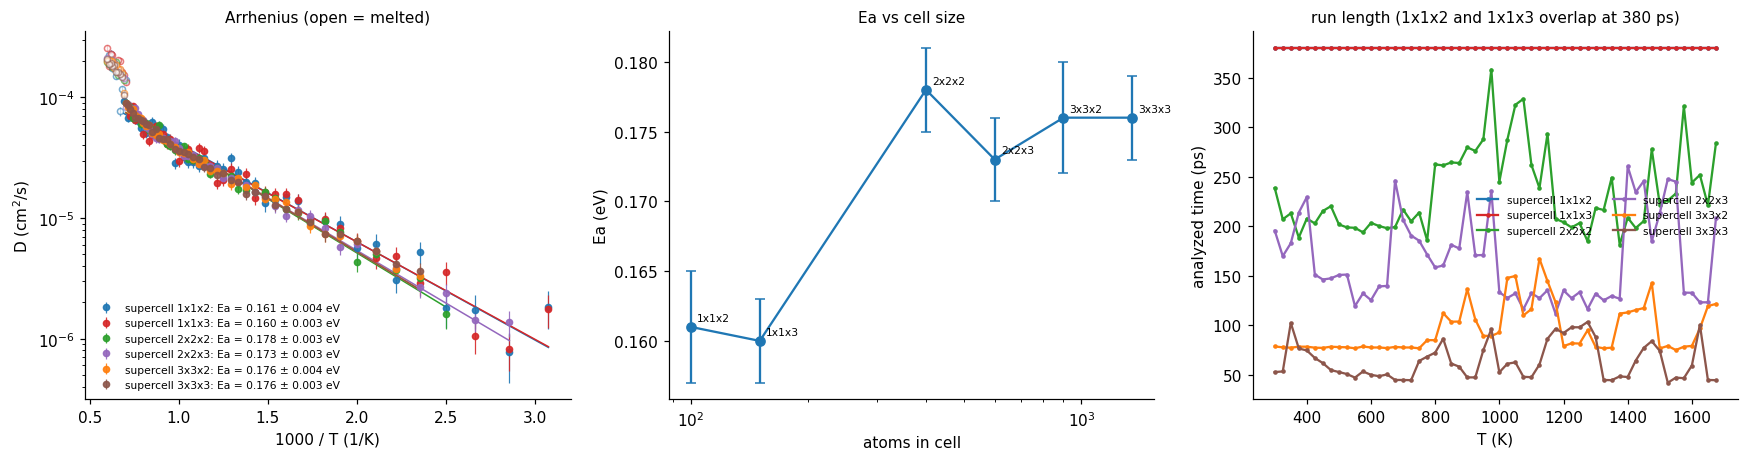

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for s, c in zip(doc["series"], PALETTE):
    mr.arrhenius_plot(axes[0], s, c, label=s["label"])
axes[0].legend(frameon=False, fontsize=7, loc="lower left"); axes[0].set_title("Arrhenius (open = melted)")
x = t["atoms"]; axes[1].errorbar(x, t["Ea (eV)"], yerr=t["Ea std (eV)"], fmt="o-", capsize=3)
for l, xi, yi in zip(t.index, x, t["Ea (eV)"]):
    axes[1].annotate(l.replace("supercell ", ""), (xi, yi), textcoords="offset points", xytext=(4, 4), fontsize=7)
axes[1].set_xscale("log"); axes[1].set_xlabel("atoms in cell"); axes[1].set_ylabel("Ea (eV)"); axes[1].set_title("Ea vs cell size")
for s, c in zip(doc["series"], PALETTE):
    T = [r["temperature_K"] for r in s["temperatures"]]
    axes[2].plot(T, [r.get("analyzed_time_ps", 0) for r in s["temperatures"]], "o-", ms=2, color=c, label=s["label"])
axes[2].set_xlabel("T (K)"); axes[2].set_ylabel("analyzed time (ps)"); axes[2].set_title("run length (1x1x2 and 1x1x3 overlap at 380 ps)")
axes[2].legend(frameon=False, fontsize=7, ncol=2)
fig.tight_layout(); save(fig, "md/lgps_supercell_size")

In [3]:
melt = {}
for s in doc["series"]:
    melted = [r["temperature_K"] for r in s["temperatures"] if r.get("framework_melt_flag")]
    solid = [r["temperature_K"] for r in s["temperatures"] if r.get("fit_ok") and not r.get("framework_melt_flag")]
    melt[s["label"]] = {"highest solid T (K)": max(solid) if solid else None, "lowest melted T (K)": min(melted) if melted else None,
                        "melted temperatures": len(melted)}
pd.DataFrame(melt).T

,highest solid T (K),lowest melted T (K),melted temperatures
supercell 1x1x2,1450.0,1425.0,10.0
supercell 1x1x3,1400.0,1425.0,11.0
supercell 2x2x2,1425.0,1450.0,10.0
supercell 2x2x3,1375.0,1400.0,12.0
supercell 3x3x2,1425.0,1450.0,10.0
supercell 3x3x3,1425.0,1450.0,10.0


In [4]:
mr.fit_comparison(doc, ["all (no framework melt)", "all", "all (unweighted)", "500-1000K (no framework melt)"])

,all (no framework melt),all,all (unweighted),500-1000K (no framework melt)
supercell 1x1x2,0.161,0.208,0.175,0.141
supercell 1x1x3,0.160,0.220,0.181,0.139
supercell 2x2x2,0.178,0.229,0.198,0.161
supercell 2x2x3,0.173,0.221,0.189,0.159
supercell 3x3x2,0.176,0.229,0.196,0.154
supercell 3x3x3,0.176,0.224,0.193,0.157


## Findings

* **E<sub>a</sub> is converged from the 2×2×2 cell (400 atoms) on.** The four cells with 400–1,350
  atoms give 0.173–0.178 eV (±0.003–0.004 eV); the two smallest cells (100 and 150 atoms) give
  0.160–0.161 eV.
* **Small cells overestimate the room-temperature conductivity.** Extrapolated σ(300 K) is 66–67 mS/cm
  for 100–150 atoms and 41–47 mS/cm for 400–1,350 atoms.
* **Melting onset is size independent:** the framework melts from 1400–1450 K in every cell; excluding
  those temperatures changes E<sub>a</sub> by about 0.05 eV (e.g. 2×2×2: 0.229 → 0.178 eV).
* **Larger cells reach statistics sooner.** The largest cells ran only 59–217 ps (median) before the
  wall time, but they contain up to 13.5× more Li, so their fits are as tight (R² 0.983–0.989) as the
  380 ps runs of the small cells (R² 0.966).
* The 500–1000 K window gives lower values (0.139–0.161 eV) than the full 325–1450 K range, so the
  reported E<sub>a</sub> depends on the temperature range, as expected if the mechanism changes with T.